In [19]:
import numpy as np
import pyplot as plot
import segmentation as seg

import model as mod
import motion
import dtw as dtw_lib

from mpl_toolkits.mplot3d import Axes3D
from kinematics import Joint
import matplotlib as mat

mat.use("ipympl")

In [20]:
print("Loading model and normalizing...")
ref1 = motion.MotionStream("../assets/MCPM_20260612_135307.bvh")
ref2 = motion.MotionStream("../assets/MCPM_20260612_135327.bvh")
ref3 = motion.MotionStream("../assets/MCPM_20260612_135338.bvh")
ref4 = motion.MotionStream("../assets/MCPM_20260612_135430.bvh")
ref5 = motion.MotionStream("../assets/MCPM_20260612_135445.bvh")
stream = motion.MotionStream("../assets/MCPM_20260612_135850.bvh")

Loading model and normalizing...


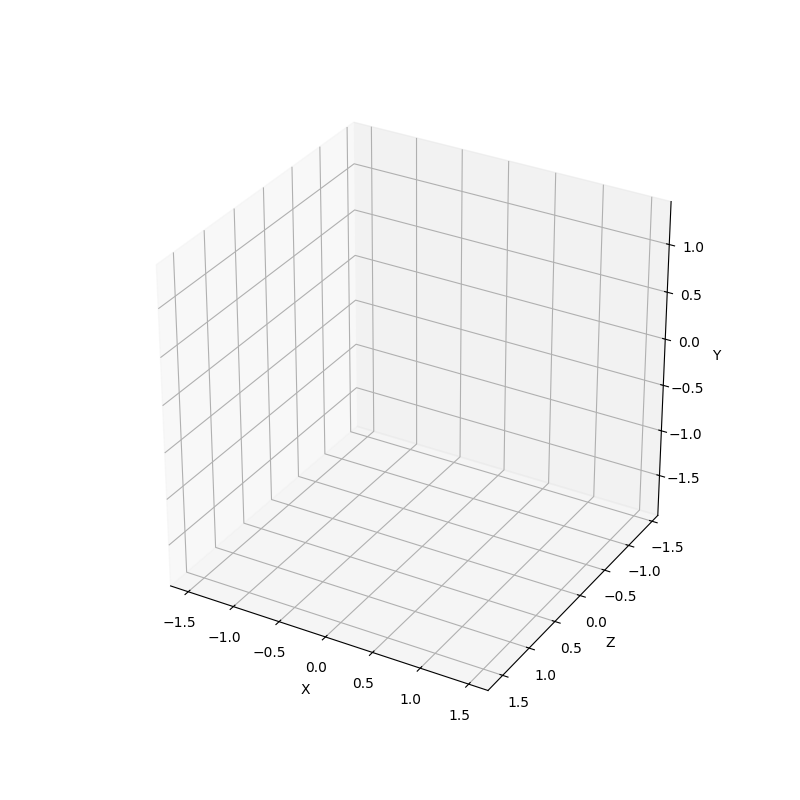

In [21]:
view       = stream
frames     = []
for frame, _ in view:
    frames.append(frame)

# print("Plotting...")
ani = plot.plot_skeleton(frames)

In [18]:
detector = seg.GaitDetector([
    (dtw_lib.LiveDTW(ref1), "Pick up 1")
])

detector.calibrate(stream)
for (_, name), t in zip(detector.gaits, detector.thresholds):
    print(f"  {name}: threshold = {t:.4f}")

detected = detector.detect(stream)
print()
for begin, end, label in detected:
    print(f"[{begin}:{end}] {label}")

  Pick up 1: threshold = 0.2010

[748:888] Pick up 1


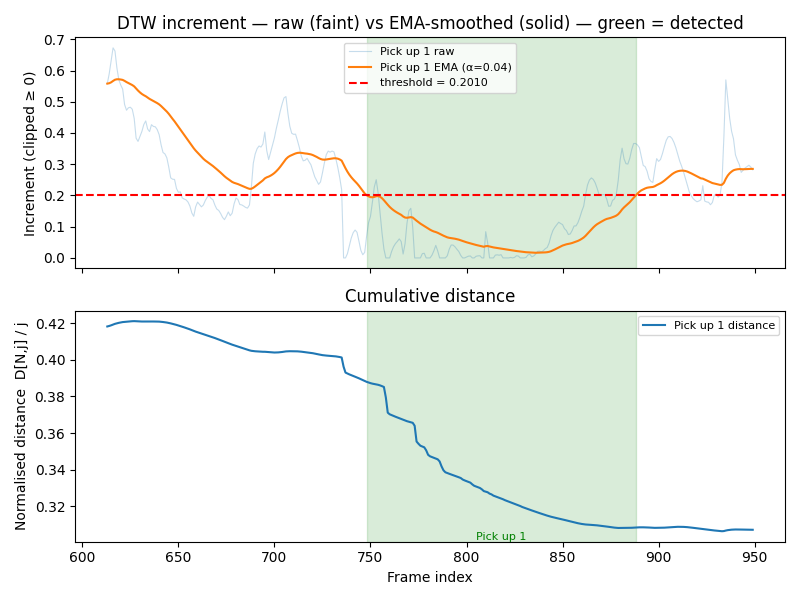

In [28]:
import matplotlib.pyplot as plt

EMA_ALPHA     = detector.ema_alpha
WARMUP_FRAMES = detector.warmup_frames

# Mirror the gaits definition — names stay in sync automatically.
_probe_refs = [ref1, ref2, ref3, ref4, ref5]
_probes = [
    (dtw_lib.LiveDTW(_probe_refs[i]), name)
    for i, (_, name) in enumerate(detector.gaits)
]

_raw_inc:  dict[str, list] = {name: [] for _, name in _probes}
_ema_inc:  dict[str, list] = {name: [] for _, name in _probes}
_dist:     dict[str, list] = {name: [] for _, name in _probes}
_ema_state = [float("nan")] * len(_probes)
_frames    = []

for frame_index, (_, vel) in enumerate(stream):
    _frames.append(frame_index)
    for i, (probe, name) in enumerate(_probes):
        if vel is None:
            _raw_inc[name].append(float("nan"))
            _ema_inc[name].append(float("nan"))
            _dist[name].append(float("nan"))
            continue
        probe.update(vel)
        ready = probe.frames_seen >= probe._N + WARMUP_FRAMES
        if ready:
            raw = probe.increment
            _ema_state[i] = (
                raw if np.isnan(_ema_state[i])
                else EMA_ALPHA * raw + (1 - EMA_ALPHA) * _ema_state[i]
            )
            _raw_inc[name].append(raw)
            _ema_inc[name].append(_ema_state[i])
            _dist[name].append(probe.distance)
        else:
            _raw_inc[name].append(float("nan"))
            _ema_inc[name].append(float("nan"))
            _dist[name].append(float("nan"))

for probe, _ in _probes:
    probe.reset()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
xs = _frames

for i, (_, name) in enumerate(_probes):
    t = detector.thresholds[i]
    axes[0].plot(xs, _raw_inc[name], alpha=0.25, linewidth=0.8,
                 label=f"{name} raw")
    axes[0].plot(xs, _ema_inc[name], linewidth=1.5,
                 label=f"{name} EMA (α={EMA_ALPHA})")
    axes[0].axhline(t, linestyle="--", color="red",
                    label=f"threshold = {t:.4f}")
    axes[1].plot(xs, _dist[name], label=f"{name} distance")

for begin, end, label in detected:
    for ax in axes:
        ax.axvspan(begin, end, alpha=0.15, color="green")
    axes[1].annotate(label, xy=((begin + end) / 2, 0),
                     xycoords=("data", "axes fraction"),
                     ha="center", va="bottom", fontsize=8, color="green")

axes[0].set_ylabel("Increment (clipped ≥ 0)")
axes[0].set_title(
    "DTW increment — raw (faint) vs EMA-smoothed (solid) — green = detected"
)
axes[0].legend(fontsize=8)
axes[1].set_ylabel("Normalised distance  D[N,j] / j")
axes[1].set_title("Cumulative distance")
axes[1].legend(fontsize=8)
axes[1].set_xlabel("Frame index")

plt.tight_layout()
plt.show()

In [6]:
# Profiling / Benchmarking
import cProfile
import pstats

with cProfile.Profile() as pr:
    stream = motion.MotionStream("../assets/MCPM_20260612_135327.bvh")

stats = pstats.Stats(pr)
stats.sort_stats('cumulative')
stats.print_stats(15)  # top 15 slowest calls

         336904 function calls (255882 primitive calls) in 1.257 seconds

   Ordered by: cumulative time
   List reduced from 232 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    314/9    0.005    0.000    1.212    0.135 /home/airgeddon1337/Project/KMITL/SENDAI/dance-notation-etl/src/motion.py:250(_normalize)
        1    0.002    0.002    1.050    1.050 /home/airgeddon1337/Project/KMITL/SENDAI/dance-notation-etl/src/motion.py:110(__init__)
90118/26376    0.379    0.000    0.489    0.000 /home/airgeddon1337/Project/KMITL/SENDAI/dance-notation-etl/src/kinematics.py:40(_invalidate)
    17584    0.063    0.000    0.480    0.000 /home/airgeddon1337/Project/KMITL/SENDAI/dance-notation-etl/src/kinematics.py:209(offset)
     8164    0.048    0.000    0.213    0.000 /home/airgeddon1337/Project/KMITL/SENDAI/dance-notation-etl/src/kinematics.py:225(append)
     8478    0.088    0.000    0.156    0.000 /home/airgeddon1337/Project/KMITL/SEN